# **Homework 14**

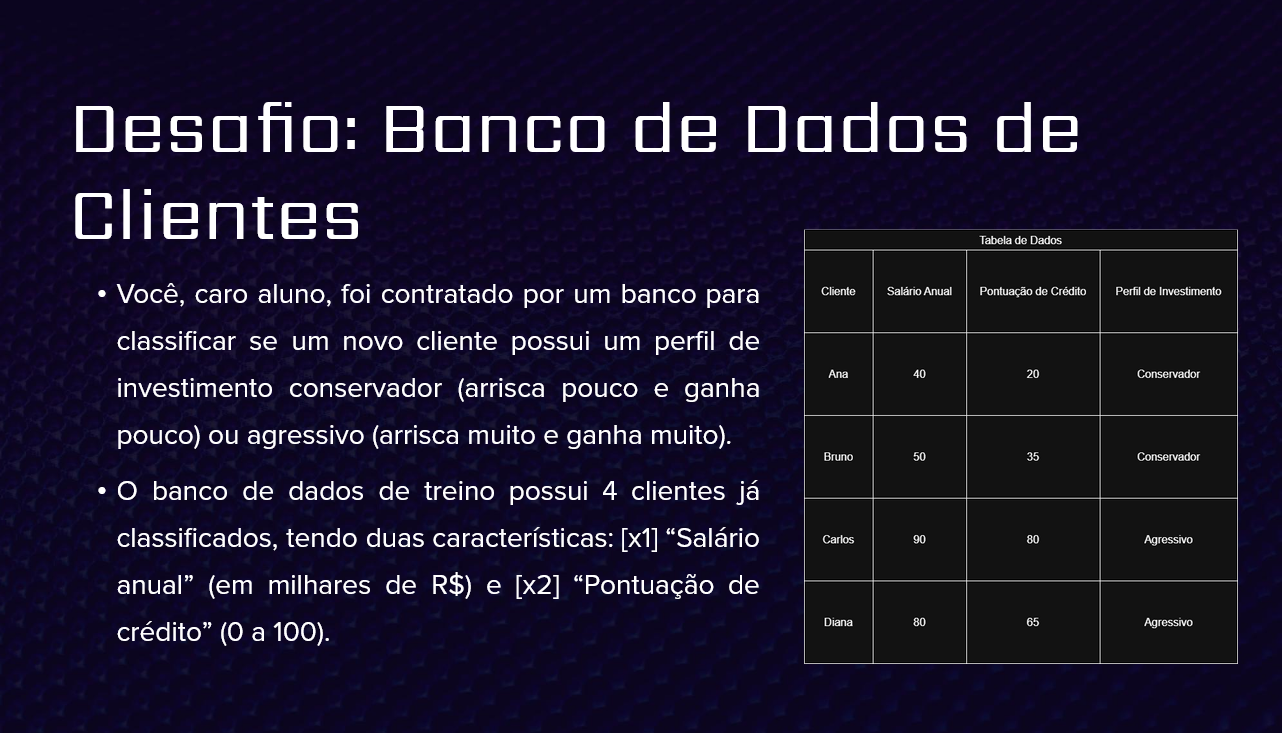

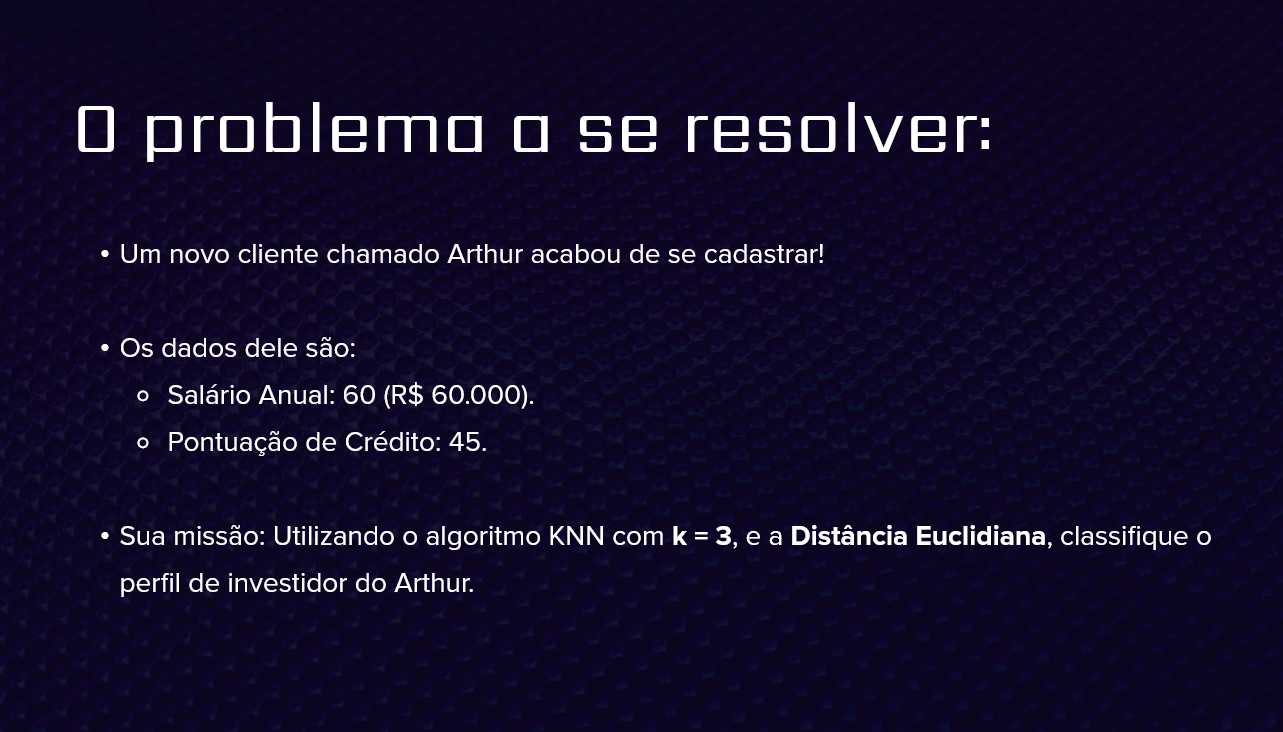

### K-Nearest Neighbors (KNN) for Text Classification

This section implements a basic K-Nearest Neighbors algorithm for text classification. The general steps involve:
1.  **Text Vectorization**: Converting text data into numerical format using techniques like TF-IDF.
2.  **Data Splitting**: Dividing the dataset into training and testing sets.
3.  **Model Training**: Training the KNN classifier on the training data.
4.  **Prediction**: Using the trained model to predict categories for new text.
5.  **Evaluation**: Assessing the model's performance.

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Modifying the existing knn function to implement text classification.
def knn_text_classifier(documents=None, labels=None, n_neighbors=3):
    """Implements a K-Nearest Neighbors (KNN) classifier for text data.

    This function performs text vectorization using TF-IDF, splits the data
    into training and testing sets, trains a KNN model, and evaluates its performance.
    If no documents or labels are provided, a dummy dataset is used for demonstration.

    Args:
        documents (list, optional): A list of text strings (documents) for classification.
                                    Defaults to None, in which case a dummy dataset is used.
        labels (list, optional): A list of corresponding labels for the documents.
                                 Defaults to None, used with the dummy dataset.
        n_neighbors (int, optional): The number of neighbors to consider for KNN. Defaults to 3.

    Returns:
        tuple: A tuple containing:
            - knn_model (KNeighborsClassifier): The trained KNN model.
            - vectorizer (TfidfVectorizer): The fitted TF-IDF vectorizer.
    """
    if documents is None or labels is None:
        print("No data provided. Using a dummy dataset for demonstration.")
        # Dummy dataset for demonstration if no data is provided.
        documents = [
            "This is a fantastic movie! I loved the plot and acting.",
            "What a great film, I highly recommend it.",
            "The cinema experience was superb, definitely a must-watch.",
            "Terrible acting and a very bad plot. I wouldn't watch again.",
            "I hated every single minute of this film. A complete waste of time.",
            "The worst movie I have ever seen. Absolutely dreadful.",
            "It was an okay film, not great but not terrible.",
            "It was an average experience, nothing special." # Added to ensure 'neutral' has more than one sample.
        ]
        labels = ["positive", "positive", "positive", "negative", "negative", "negative", "neutral", "neutral"] # Added label for the new sample.

    print("\n--- Data Preprocessing ---")
    print(f"Number of documents: {len(documents)}")
    print(f"Number of labels: {len(labels)}")

    # 1. Text Vectorization using TF-IDF.
    # Convert a collection of raw documents to a matrix of TF-IDF features.
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(documents)
    y = labels

    print(f"Shape of vectorized data (documents x features): {X.shape}")

    # 2. Split data into training and testing sets.
    # 70% for training, 30% for testing.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y if len(set(y)) > 1 else None)

    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Testing set size: {X_test.shape[0]} samples")

    print("\n--- Model Training ---")
    # 3. Train KNN classifier.
    # Initialize KNeighborsClassifier with n_neighbors.
    knn_model = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn_model.fit(X_train, y_train)

    print(f"KNN model trained with {n_neighbors} neighbors.")

    print("\n--- Model Evaluation ---")
    # 4. Make predictions on the test set.
    y_pred = knn_model.predict(X_test)

    # 5. Evaluate the model.
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"KNN Classifier Accuracy: {accuracy:.2f}")
    print("\nClassification Report:\n", report)

    return knn_model, vectorizer

### Run the KNN Text Classifier

Now, let's execute the `knn_text_classifier` function. You can either use the default dummy dataset or provide your own `documents` and `labels` lists.


In [4]:
# Example usage:
# model, vectorizer = knn_text_classifier(n_neighbors=3)

# If you have your own data, uncomment and replace with your lists:
# my_documents = ["This is good.", "Bad experience.", "Neutral comment."]
# my_labels = ["positive", "negative", "neutral"]
# model, vectorizer = knn_text_classifier(documents=my_documents, labels=my_labels, n_neighbors=3)

# For now, we'll use the dummy data within the function
model, vectorizer = knn_text_classifier(n_neighbors=3)

print("\n--- Making a New Prediction ---")
new_text = ["This was an absolutely terrible film, don't waste your money."]
new_text_vectorized = vectorizer.transform(new_text)
prediction = model.predict(new_text_vectorized)

print(f"New text: '{new_text[0]}'")
print(f"Predicted category: {prediction[0]}")

No data provided. Using a dummy dataset for demonstration.

--- Data Preprocessing ---
Number of documents: 8
Number of labels: 8
Shape of vectorized data (documents x features): (8, 48)
Training set size: 5 samples
Testing set size: 3 samples

--- Model Training ---
KNN model trained with 3 neighbors.

--- Model Evaluation ---
KNN Classifier Accuracy: 0.33

Classification Report:
               precision    recall  f1-score   support

    negative       0.50      1.00      0.67         1
     neutral       0.00      0.00      0.00         1
    positive       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.17      0.33      0.22         3
weighted avg       0.17      0.33      0.22         3


--- Making a New Prediction ---
New text: 'This was an absolutely terrible film, don't waste your money.'
Predicted category: negative


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
